# BriefMe `arg_summ` — raw vs seq2seq mapping

## Setup

1. **Environment (recommended):** from repo root, `conda env create -f environment.yml`, `conda activate cs474`, `pip install -e ".[dev]"` — see [README.md](../README.md). Or: `pip install -r requirements.txt` in a venv and `pip install -e ".[dev]"`.
2. Copy `.env.example` to `.env` and set `HUGGINGFACE_HUB_TOKEN` ([create a token](https://huggingface.co/settings/tokens)).
3. Run this notebook with a kernel that has the project installed, or cwd = **repo root** / **`notebooks/`** (the first code cell adds `src/` to the path if `briefme` is not on `PYTHONPATH`).

**Colab:** put the token in Colab secrets or `os.environ["HUGGINGFACE_HUB_TOKEN"] = "..."` — `.env` is not loaded automatically.

Data is cached on disk under the Hugging Face cache (e.g. `~/.cache/huggingface/datasets`), not in a SQL/NoSQL database.

**Note:** Full `load_dataset(..., streaming=False)` can fail while building cache (upstream issue on the empty `held_out` split vs schema). This notebook uses **streaming + materialize first N rows** via `briefme.data` so EDA runs reliably.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

from dotenv import load_dotenv


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

load_dotenv(REPO_ROOT / ".env")

from datasets import get_dataset_config_names

from briefme.data import (
    SPLIT_TRAIN,
    load_arg_summ_split_streaming,
    materialize_head,
)
from briefme.schema import (
    CONFIG_NAME,
    DATASET_NAME,
    SOURCE_COLUMN,
    TARGET_COLUMN,
    to_seq2seq_example,
)

if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    print(
        "Note: No HUGGINGFACE_HUB_TOKEN / HF_TOKEN set. "
        "Public datasets may still load; gated repos need .env (see .env.example)."
    )

In [2]:
configs = get_dataset_config_names(DATASET_NAME)
print("Available configs:", configs)
assert CONFIG_NAME in configs, f"Expected {CONFIG_NAME} in {configs}"

# Streaming avoids Hub cache failure on held_out split (see notebook intro).
EDA_N = 2000  # materialize this many train rows for plots + samples
train_eda = materialize_head(load_arg_summ_split_streaming(SPLIT_TRAIN), EDA_N)
print("Materialized train head:", len(train_eda), "rows")
print("Features:\n", train_eda.features)
print("Hub splits (streaming): train, dev, test — use load_arg_summ_split_streaming(name)")

Available configs: ['arg_comp', 'arg_summ', 'case_retrieval', 'retrieval_corpus', 'preprocessed']
Materialized train head: 2000 rows
Features:
 {'file': Value('string'), 'text': Value('string'), 'reference': Value('string'), 'judge_outcome': Value('string'), 'judge_score_verb': Value('string'), 'judge_score': Value('int64')}
Hub splits (streaming): train, dev, test — use load_arg_summ_split_streaming(name)


In [3]:
train = train_eda
n_show = min(3, len(train))
print(f"Showing {n_show} raw rows (columns: text, reference, file, judge_* )\n")
for i in range(n_show):
    row = train[i]
    print("===", i, "===")
    print("file:", row.get("file"))
    print("reference (gold heading):", row.get("reference"))
    print("text (excerpt):", (row.get("text") or "")[:800], "..." if len(row.get("text") or "") > 800 else "")
    print()

Showing 3 raw rows (columns: text, reference, file, judge_* )

=== 0 ===
file: Docket19-930_Brief002.pdf
reference (gold heading): INTRODUCTION: THE CURRENT SCOPE OF THE AIA AS INTERPRETED BY THE SIXTH CIRCUIT REACHES TOO BROADLY
text (excerpt): It may seem odd that a low-income taxpayer clinic 
is weighing in on a case involving a tax advisor to 
§ 831(b) captive insurance companies. After all, our clients generally do not encounter the same type of tax 
shelter scrutiny facing CIC Services (hereinafter CIC). 
However, this case exposes a fundamental tension be-tween the Administrative Procedure Act (APA) and the 
Anti-Injunction Act (AIA) which, if resolved incorrectly, 
would disproportionately harm low-income taxpayers.  
4 
  The Tax Clinic made a similar argument to the 
Second Circuit in the case of Larson v. United States , 
888 F.3d 578 (2d Cir. 2018), which also involved activ-
ity targeted by the IRS as a tax shelter. While the Larson  case differs factually  and procedurall

In [4]:
print("Mapped seq2seq pairs: source =", repr(SOURCE_COLUMN), " target =", repr(TARGET_COLUMN))
for i in range(n_show):
    ex = to_seq2seq_example(train[i])
    print("===", i, "===")
    print("metadata:", ex["metadata"])
    print("target:", ex["target"])
    print("source (excerpt):", ex["source"][:800], "..." if len(ex["source"]) > 800 else "")
    print()

Mapped seq2seq pairs: source = 'text'  target = 'reference'
=== 0 ===
metadata: {'file': 'Docket19-930_Brief002.pdf'}
target: INTRODUCTION: THE CURRENT SCOPE OF THE AIA AS INTERPRETED BY THE SIXTH CIRCUIT REACHES TOO BROADLY
source (excerpt): It may seem odd that a low-income taxpayer clinic 
is weighing in on a case involving a tax advisor to 
§ 831(b) captive insurance companies. After all, our clients generally do not encounter the same type of tax 
shelter scrutiny facing CIC Services (hereinafter CIC). 
However, this case exposes a fundamental tension be-tween the Administrative Procedure Act (APA) and the 
Anti-Injunction Act (AIA) which, if resolved incorrectly, 
would disproportionately harm low-income taxpayers.  
4 
  The Tax Clinic made a similar argument to the 
Second Circuit in the case of Larson v. United States , 
888 F.3d 578 (2d Cir. 2018), which also involved activ-
ity targeted by the IRS as a tax shelter. While the Larson  case differs factually  and procedurally f

Source (text) char length — min=89  p50=4978  p90=13030  p95=17223  p99=41037  max=162700
Rows with length > p99: 20 (1.00%) → thin right tail



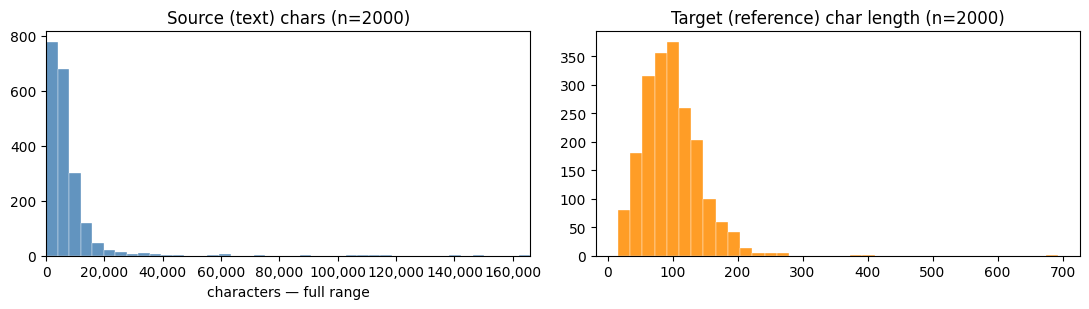

In [7]:
# Length distribution (character counts) — check right tail on source text, then zoom x-axis sensibly
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

comma_ticks = FuncFormatter(lambda x, p: f"{x:,.0f}")

sample_n = len(train)
src_lens = [len(train[i][SOURCE_COLUMN] or "") for i in range(sample_n)]
tgt_lens = [len(train[i][TARGET_COLUMN] or "") for i in range(sample_n)]

src_arr = np.asarray(src_lens, dtype=np.float64)
p50, p90, p95, p99 = np.percentile(src_arr, [50, 90, 95, 99])
mx = float(src_arr.max())
mn = float(src_arr.min())
n_gt_p99 = int(np.sum(src_arr > p99))
frac_gt_p99 = n_gt_p99 / sample_n
# Thin tail = few rows past p99 relative to bulk (long documents are rare)
thin_right_tail = n_gt_p99 <= max(10, round(0.015 * sample_n))

print(f"Source ({SOURCE_COLUMN}) char length — min={mn:.0f}  p50={p50:.0f}  p90={p90:.0f}  p95={p95:.0f}  p99={p99:.0f}  max={mx:.0f}")
print(f"Rows with length > p99: {n_gt_p99} ({100 * frac_gt_p99:.2f}%) → {'thin right tail' if thin_right_tail else 'LONG right tail — x-axis capped at p99 for main view'}")
print()

# Source hist: zoom to bulk; cap at p99 only when tail is visibly heavy so the peak is centered in view
src_xmax = mx * 1.02 if thin_right_tail else p99

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(src_lens, bins=42, range=(0.0, src_xmax), color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.3)
ax[0].set_xlim(0.0, src_xmax)
ax[0].set_title(f"Source ({SOURCE_COLUMN}) chars (n={sample_n})")
tag = "full range" if thin_right_tail else "zoomed to p99 — see max above"
ax[0].set_xlabel(f"characters — {tag}")

ax[1].hist(tgt_lens, bins=36, color="darkorange", alpha=0.85, edgecolor="white", linewidth=0.3)
ax[1].set_title(f"Target ({TARGET_COLUMN}) char length (n={sample_n})")

for a in ax:
    a.xaxis.set_major_formatter(comma_ticks)
    a.yaxis.set_major_formatter(comma_ticks)

plt.tight_layout()
plt.show()